# Tarea 2:



## 1. Configuración del entorno

In [1]:
!pip install -q -U "jax[cuda12]" flax optax kagglehub

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.1/40.1 kB 2.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 525.1/525.1 kB 16.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 70.6/70.6 kB 3.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 73.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 64.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 164.8/164.8 MB 6.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 85.8/85.8 MB 8.1 MB/s eta 0:00:00


In [2]:
import jax
import jax.numpy as jnp
from flax import nnx
import optax
import numpy as np
import time
import matplotlib.pyplot as plt

print("Dispositivos:", jax.devices())
print("Cantidad de dispositivos:", jax.device_count())
print("Backend:", jax.default_backend())

Dispositivos: [CudaDevice(id=0)]
Cantidad de dispositivos: 1
Backend: gpu


## 2. Dataset: Wonders of the World

Se descarga directamente desde Kaggle con `kagglehub` (no requiere API key en Colab).

In [3]:
import kagglehub, os

path = kagglehub.dataset_download("balabaskar/wonders-of-the-world-image-classification")
print("Ruta del dataset:", path)

for root, dirs, files in os.walk(path):
    depth = root.replace(path, '').count(os.sep)
    if depth <= 2:
        print('  ' * depth + os.path.basename(root) + f"  ({len(files)} archivos)")

Using Colab cache for faster access to the 'wonders-of-the-world-image-classification' dataset.
Ruta del dataset: /kaggle/input/wonders-of-the-world-image-classification
wonders-of-the-world-image-classification  (1 archivos)
  Wonders of World  (0 archivos)
    Wonders of World  (0 archivos)


In [4]:
import glob

def find_class_root(base):
    for root, dirs, files in os.walk(base):

        if len(dirs) >= 5:
            sub_ok = all(
                any(f.lower().endswith(('.jpg', '.jpeg', '.png')) for f in os.listdir(os.path.join(root, d)))
                for d in dirs[:3]
            )
            if sub_ok:
                return root
    return base

DATA_DIR = find_class_root(path)
CLASSES = sorted([d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))])
NUM_CLASSES = len(CLASSES)
print(f"{NUM_CLASSES} clases encontradas:")
for c in CLASSES:
    n = len(os.listdir(os.path.join(DATA_DIR, c)))
    print(f"  {c}: {n} imágenes")

12 clases encontradas:
  burj_khalifa: 390 imágenes
  chichen_itza: 340 imágenes
  christ_the_reedemer: 323 imágenes
  eiffel_tower: 391 imágenes
  great_wall_of_china: 392 imágenes
  machu_pichu: 393 imágenes
  pyramids_of_giza: 372 imágenes
  roman_colosseum: 394 imágenes
  statue_of_liberty: 238 imágenes
  stonehenge: 204 imágenes
  taj_mahal: 158 imágenes
  venezuela_angel_falls: 251 imágenes


### Preprocesamiento

Decisiones adoptadas (documentadas para el informe):
- **Resolución 64×64**: balance entre detalle suficiente para distinguir monumentos y costo computacional viable en una sola GPU/TPU de Colab.
- **Normalización a [0,1]**: dividir entre 255 estabiliza el entrenamiento.
- **Split 70/15/15** (train/val/test) estratificado por clase, con semilla fija para reproducibilidad.
- Todo el dataset se carga en memoria como arrays de NumPy (≈4k imágenes a 64×64 caben sin problema), lo que permite un pipeline simple y rápido hacia el acelerador.

In [5]:
from PIL import Image

IMG_SIZE = 64
SEED = 42

def load_dataset(data_dir, classes, img_size):
    X, y = [], []
    for label, cls in enumerate(classes):
        cls_dir = os.path.join(data_dir, cls)
        for fname in os.listdir(cls_dir):
            if not fname.lower().endswith(('.jpg', '.jpeg', '.png')):
                continue
            try:
                img = Image.open(os.path.join(cls_dir, fname)).convert('RGB')
                img = img.resize((img_size, img_size))
                X.append(np.asarray(img, dtype=np.uint8))
                y.append(label)
            except Exception:
                pass
    return np.stack(X), np.array(y, dtype=np.int32)

X, y = load_dataset(DATA_DIR, CLASSES, IMG_SIZE)
print("Imágenes:", X.shape, "| Etiquetas:", y.shape)

Imágenes: (3846, 64, 64, 3) | Etiquetas: (3846,)


In [6]:
rng = np.random.default_rng(SEED)

train_idx, val_idx, test_idx = [], [], []
for c in range(NUM_CLASSES):
    idx = np.where(y == c)[0]
    rng.shuffle(idx)
    n = len(idx)
    n_tr, n_val = int(0.70 * n), int(0.15 * n)
    train_idx += list(idx[:n_tr])
    val_idx   += list(idx[n_tr:n_tr + n_val])
    test_idx  += list(idx[n_tr + n_val:])

train_idx, val_idx, test_idx = map(np.array, (train_idx, val_idx, test_idx))
rng.shuffle(train_idx)

X_train, y_train = X[train_idx].astype(np.float32) / 255.0, y[train_idx]
X_val,   y_val   = X[val_idx].astype(np.float32) / 255.0,   y[val_idx]
X_test,  y_test  = X[test_idx].astype(np.float32) / 255.0,  y[test_idx]

print(f"Train: {X_train.shape[0]} | Val: {X_val.shape[0]} | Test: {X_test.shape[0]}")

Train: 2686 | Val: 570 | Test: 590


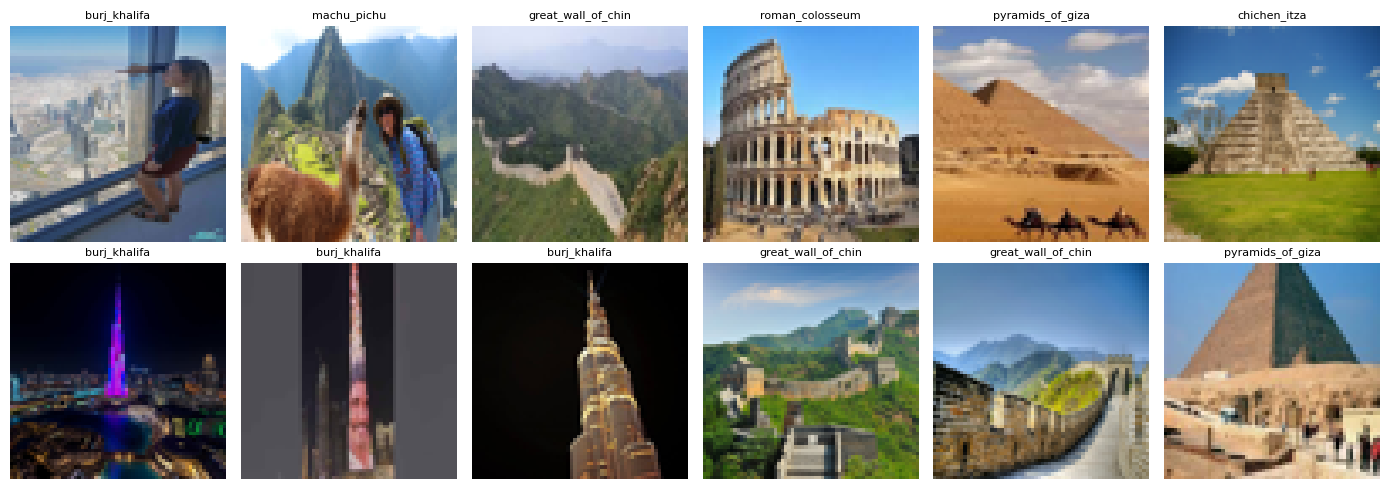

In [7]:
fig, axes = plt.subplots(2, 6, figsize=(14, 5))
for ax in axes.flat:
    i = rng.integers(len(X_train))
    ax.imshow(X_train[i])
    ax.set_title(CLASSES[y_train[i]][:18], fontsize=8)
    ax.axis('off')
plt.tight_layout(); plt.show()

In [8]:
def batch_iter(X, y, batch_size, shuffle=True, seed=0):
    idx = np.arange(len(X))
    if shuffle:
        np.random.default_rng(seed).shuffle(idx)
    for i in range(0, len(idx) - batch_size + 1, batch_size):
        b = idx[i:i + batch_size]
        yield X[b], y[b]

## 3. Implementación del modelo (Flax NNX)

Arquitectura mínima exigida: `Conv → ReLU → MaxPool → Conv → ReLU → MaxPool → Dense → Output`, ampliada con `BatchNorm` para estabilizar el entrenamiento. El número de filtros y neuronas es parametrizable para los experimentos de tamaño de red. El parámetro `dtype` permite cambiar la precisión numérica de cómputo (sección 8).

In [9]:
class CNN(nnx.Module):
    def __init__(self, num_classes, f1=32, f2=64, dense=256,
                 img_size=64, dtype=jnp.float32, *, rngs: nnx.Rngs):
        self.dtype = dtype
        self.conv1 = nnx.Conv(3, f1, kernel_size=(3, 3), dtype=dtype, rngs=rngs)
        self.bn1   = nnx.BatchNorm(f1, dtype=dtype, rngs=rngs)
        self.conv2 = nnx.Conv(f1, f2, kernel_size=(3, 3), dtype=dtype, rngs=rngs)
        self.bn2   = nnx.BatchNorm(f2, dtype=dtype, rngs=rngs)
        feat = (img_size // 4) * (img_size // 4) * f2
        self.fc1 = nnx.Linear(feat, dense, dtype=dtype, rngs=rngs)
        self.fc2 = nnx.Linear(dense, num_classes, dtype=dtype, rngs=rngs)

    def __call__(self, x):
        x = x.astype(self.dtype)
        x = nnx.relu(self.bn1(self.conv1(x)))
        x = nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = nnx.relu(self.bn2(self.conv2(x)))
        x = nnx.max_pool(x, window_shape=(2, 2), strides=(2, 2))
        x = x.reshape(x.shape[0], -1)
        x = nnx.relu(self.fc1(x))
        return self.fc2(x).astype(jnp.float32)

model = CNN(NUM_CLASSES, rngs=nnx.Rngs(SEED))
logits = model(jnp.ones((2, IMG_SIZE, IMG_SIZE, 3)))
print("Salida:", logits.shape)
nnx.display(model)

Salida: (2, 12)


## 4. Entrenamiento

Componentes:
- **Pérdida**: cross-entropy con etiquetas enteras (`optax.softmax_cross_entropy_with_integer_labels`).
- **Optimizador**: Adam (Optax).
- **Diferenciación automática**: `nnx.value_and_grad`.
- **Compilación JIT**: `nnx.jit` (equivalente a `jax.jit` consciente del estado del módulo).

In [10]:
def loss_fn(model, x, y):
    logits = model(x)
    loss = optax.softmax_cross_entropy_with_integer_labels(logits, y).mean()
    return loss, logits

def make_optimizer(model, lr):
    try:
        return nnx.Optimizer(model, optax.adam(lr), wrt=nnx.Param)
    except TypeError:
        return nnx.Optimizer(model, optax.adam(lr))

def opt_update(optimizer, model, grads):
    try:
        optimizer.update(model, grads)
    except TypeError:
        optimizer.update(grads)

@nnx.jit
def train_step(model, optimizer, x, y):
    grad_fn = nnx.value_and_grad(loss_fn, has_aux=True)
    (loss, logits), grads = grad_fn(model, x, y)
    opt_update(optimizer, model, grads)
    acc = (logits.argmax(-1) == y).mean()
    return loss, acc

@nnx.jit
def eval_step(model, x, y):
    loss, logits = loss_fn(model, x, y)
    return loss, (logits.argmax(-1) == y).mean()

def evaluate(model, X, Y, batch_size=128):
    model.eval()
    losses, accs, ns = [], [], []
    for xb, yb in batch_iter(X, Y, batch_size, shuffle=False):
        l, a = eval_step(model, jnp.asarray(xb), jnp.asarray(yb))
        losses.append(float(l)); accs.append(float(a)); ns.append(len(xb))
    w = np.array(ns) / sum(ns)
    return float(np.dot(losses, w)), float(np.dot(accs, w))

In [11]:
def train(model, epochs=15, batch_size=64, lr=1e-3, verbose=True):
    optimizer = make_optimizer(model, lr)
    history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': [],
               'epoch_times': []}
    n_images = 0
    t_total = time.perf_counter()
    for epoch in range(epochs):
        model.train()
        t0 = time.perf_counter()
        ep_loss, ep_acc, nb = 0.0, 0.0, 0
        for xb, yb in batch_iter(X_train, y_train, batch_size, seed=SEED + epoch):
            l, a = train_step(model, optimizer, jnp.asarray(xb), jnp.asarray(yb))
            ep_loss += float(l); ep_acc += float(a); nb += 1
            n_images += len(xb)
        jax.block_until_ready(l)
        dt = time.perf_counter() - t0
        vl, va = evaluate(model, X_val, y_val)
        history['train_loss'].append(ep_loss / nb)
        history['train_acc'].append(ep_acc / nb)
        history['val_loss'].append(vl)
        history['val_acc'].append(va)
        history['epoch_times'].append(dt)
        if verbose:
            print(f"Época {epoch+1:2d}/{epochs} | loss {ep_loss/nb:.4f} | "
                  f"acc {ep_acc/nb:.3f} | val_acc {va:.3f} | {dt:.2f}s")
    total = time.perf_counter() - t_total
    history['total_time'] = total
    history['throughput'] = n_images / sum(history['epoch_times'])
    return history

In [12]:
model = CNN(NUM_CLASSES, rngs=nnx.Rngs(SEED))
hist = train(model, epochs=15, batch_size=64, lr=1e-3)

test_loss, test_acc = evaluate(model, X_test, y_test)
print(f"\nTiempo total: {hist['total_time']:.1f}s | "
      f"Promedio/época: {np.mean(hist['epoch_times']):.2f}s | "
      f"Throughput: {hist['throughput']:.0f} img/s")
print(f"Exactitud train: {hist['train_acc'][-1]:.3f} | "
      f"val: {hist['val_acc'][-1]:.3f} | test: {test_acc:.3f}")

Época  1/15 | loss 4.2676 | acc 0.263 | val_acc 0.201 | 3.50s
Época  2/15 | loss 1.5716 | acc 0.479 | val_acc 0.291 | 0.44s
Época  3/15 | loss 1.2120 | acc 0.625 | val_acc 0.301 | 0.49s
Época  4/15 | loss 0.9466 | acc 0.705 | val_acc 0.346 | 0.47s
Época  5/15 | loss 0.7108 | acc 0.788 | val_acc 0.354 | 0.50s
Época  6/15 | loss 0.5403 | acc 0.846 | val_acc 0.428 | 0.47s
Época  7/15 | loss 0.3991 | acc 0.894 | val_acc 0.463 | 0.45s
Época  8/15 | loss 0.2958 | acc 0.927 | val_acc 0.566 | 0.44s
Época  9/15 | loss 0.2135 | acc 0.954 | val_acc 0.533 | 0.44s
Época 10/15 | loss 0.1545 | acc 0.972 | val_acc 0.676 | 0.44s
Época 11/15 | loss 0.0993 | acc 0.987 | val_acc 0.723 | 0.44s
Época 12/15 | loss 0.0663 | acc 0.994 | val_acc 0.770 | 0.44s
Época 13/15 | loss 0.0452 | acc 0.998 | val_acc 0.766 | 0.44s
Época 14/15 | loss 0.0346 | acc 0.998 | val_acc 0.783 | 0.44s
Época 15/15 | loss 0.0299 | acc 0.999 | val_acc 0.777 | 0.44s

Tiempo total: 11.1s | Promedio/época: 0.66s | Throughput: 4006 img/s


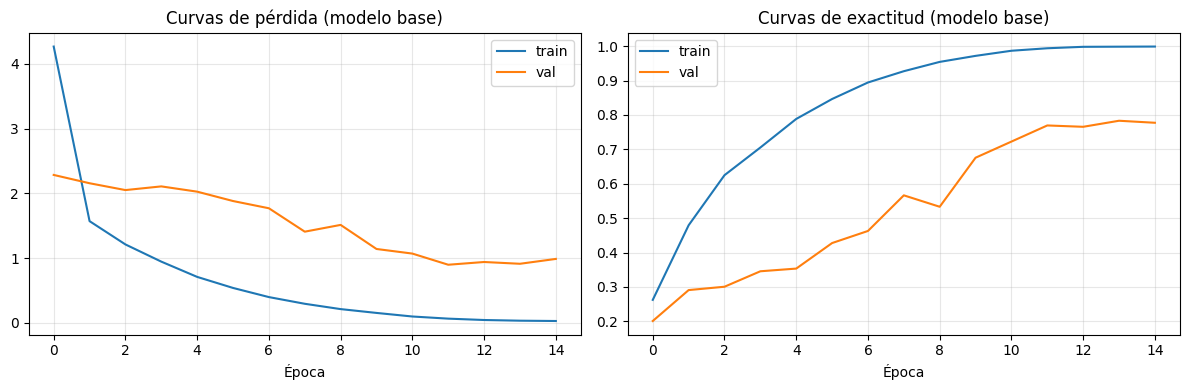

In [13]:
def plot_history(hist, title=""):
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(hist['train_loss'], label='train')
    axes[0].plot(hist['val_loss'], label='val')
    axes[0].set_title(f'Curvas de pérdida {title}'); axes[0].set_xlabel('Época'); axes[0].legend(); axes[0].grid(alpha=.3)
    axes[1].plot(hist['train_acc'], label='train')
    axes[1].plot(hist['val_acc'], label='val')
    axes[1].set_title(f'Curvas de exactitud {title}'); axes[1].set_xlabel('Época'); axes[1].legend(); axes[1].grid(alpha=.3)
    plt.tight_layout(); plt.show()

plot_history(hist, '(modelo base)')

## 5. Experimentos

Función genérica que entrena una configuración y devuelve métricas comparables.

In [14]:
import pandas as pd

def run_experiment(batch_size=64, lr=1e-3, f1=32, f2=64, dense=256,
                   epochs=10, dtype=jnp.float32, tag=""):
    model = CNN(NUM_CLASSES, f1=f1, f2=f2, dense=dense, dtype=dtype,
                rngs=nnx.Rngs(SEED))
    hist = train(model, epochs=epochs, batch_size=batch_size, lr=lr, verbose=False)
    _, test_acc = evaluate(model, X_test, y_test)
    res = {
        'config': tag or f"bs={batch_size},lr={lr},f=({f1},{f2}),d={dense},{dtype.__name__}",
        'batch_size': batch_size, 'lr': lr, 'f1': f1, 'f2': f2, 'dense': dense,
        'dtype': jnp.dtype(dtype).name, 'epochs': epochs,
        'tiempo_total_s': round(hist['total_time'], 1),
        'tiempo_por_epoca_s': round(float(np.mean(hist['epoch_times'])), 2),
        'throughput_img_s': round(hist['throughput'], 0),
        'loss_final': round(hist['val_loss'][-1], 4),
        'acc_val': round(hist['val_acc'][-1], 3),
        'acc_test': round(test_acc, 3),
    }
    print(res['config'], '→ test acc:', res['acc_test'], '|', res['tiempo_total_s'], 's')
    return res, hist

### 5.1 Impacto del tamaño de lote (32, 64, 128)

In [15]:
results_bs = []
hists_bs = {}
for bs in [32, 64, 128]:
    r, h = run_experiment(batch_size=bs, tag=f"batch_size={bs}")
    results_bs.append(r); hists_bs[bs] = h

df_bs = pd.DataFrame(results_bs)[['config','tiempo_total_s','tiempo_por_epoca_s','throughput_img_s','acc_test']]
df_bs

batch_size=32 → test acc: 0.781 | 9.2 s
batch_size=64 → test acc: 0.684 | 6.5 s
batch_size=128 → test acc: 0.391 | 7.4 s


,config,tiempo_total_s,tiempo_por_epoca_s,throughput_img_s,acc_test
0,batch_size=32,9.2,0.89,2975.0,0.781
1,batch_size=64,6.5,0.62,4236.0,0.684
2,batch_size=128,7.4,0.72,3569.0,0.391


### 5.2 Impacto de la tasa de aprendizaje (1e-2, 1e-3, 1e-4)

lr=0.01 → test acc: 0.18 | 6.4 s
lr=0.001 → test acc: 0.67 | 7.5 s
lr=0.0001 → test acc: 0.723 | 6.7 s


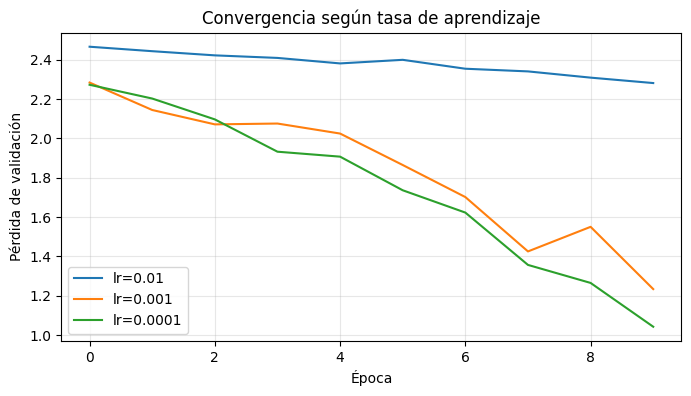

,config,loss_final,acc_val,acc_test,tiempo_total_s
0,lr=0.01,2.2817,0.197,0.180,6.4
1,lr=0.001,1.2341,0.662,0.670,7.5
2,lr=0.0001,1.0428,0.713,0.723,6.7


In [16]:
results_lr = []
hists_lr = {}
for lr in [1e-2, 1e-3, 1e-4]:
    r, h = run_experiment(lr=lr, tag=f"lr={lr}")
    results_lr.append(r); hists_lr[lr] = h

plt.figure(figsize=(8, 4))
for lr, h in hists_lr.items():
    plt.plot(h['val_loss'], label=f'lr={lr}')
plt.xlabel('Época'); plt.ylabel('Pérdida de validación')
plt.title('Convergencia según tasa de aprendizaje'); plt.legend(); plt.grid(alpha=.3); plt.show()

pd.DataFrame(results_lr)[['config','loss_final','acc_val','acc_test','tiempo_total_s']]

### 5.3 Impacto del tamaño de la red

In [17]:
results_net = []
for f1, f2 in [(32, 64), (64, 128), (128, 256)]:
    for dense in [128, 256, 512]:
        r, _ = run_experiment(f1=f1, f2=f2, dense=dense, epochs=8,
                              tag=f"filtros=({f1},{f2}), dense={dense}")
        results_net.append(r)

df_net = pd.DataFrame(results_net)[['config','tiempo_total_s','throughput_img_s','acc_test']]
df_net

filtros=(32,64), dense=128 → test acc: 0.535 | 5.9 s
filtros=(32,64), dense=256 → test acc: 0.543 | 6.0 s
filtros=(32,64), dense=512 → test acc: 0.596 | 6.5 s
filtros=(64,128), dense=128 → test acc: 0.475 | 11.3 s
filtros=(64,128), dense=256 → test acc: 0.588 | 9.5 s
filtros=(64,128), dense=512 → test acc: 0.537 | 9.7 s
filtros=(128,256), dense=128 → test acc: 0.514 | 18.4 s
filtros=(128,256), dense=256 → test acc: 0.41 | 15.9 s
filtros=(128,256), dense=512 → test acc: 0.555 | 17.5 s


,config,tiempo_total_s,throughput_img_s,acc_test
0,"filtros=(32,64), dense=128",5.9,3983.0,0.535
1,"filtros=(32,64), dense=256",6.0,3632.0,0.543
2,"filtros=(32,64), dense=512",6.5,3643.0,0.596
3,"filtros=(64,128), dense=128",11.3,2092.0,0.475
4,"filtros=(64,128), dense=256",9.5,2458.0,0.588
5,"filtros=(64,128), dense=512",9.7,2351.0,0.537
6,"filtros=(128,256), dense=128",18.4,1304.0,0.514
7,"filtros=(128,256), dense=256",15.9,1410.0,0.410
8,"filtros=(128,256), dense=512",17.5,1299.0,0.555


## 6. Optimización de hiperparámetros

Estrategia: **búsqueda en grilla reducida** (grid search) sobre las combinaciones más prometedoras de los experimentos anteriores, manteniendo el resto de valores fijos para que el costo sea viable en Colab.

In [18]:
grid = {
    'lr': [1e-3, 3e-4],
    'batch_size': [64, 128],
    'f': [(32, 64), (64, 128)],
    'dense': [256, 512],
}

results_grid = []
for lr in grid['lr']:
    for bs in grid['batch_size']:
        for f1, f2 in grid['f']:
            for d in grid['dense']:
                r, _ = run_experiment(batch_size=bs, lr=lr, f1=f1, f2=f2,
                                      dense=d, epochs=8)
                results_grid.append(r)

df_grid = pd.DataFrame(results_grid).sort_values('acc_test', ascending=False)
df_grid[['config','acc_test','loss_final','tiempo_total_s','throughput_img_s']]

bs=64,lr=0.001,f=(32,64),d=256,float32 → test acc: 0.574 | 5.7 s
bs=64,lr=0.001,f=(32,64),d=512,float32 → test acc: 0.586 | 6.0 s
bs=64,lr=0.001,f=(64,128),d=256,float32 → test acc: 0.553 | 8.6 s
bs=64,lr=0.001,f=(64,128),d=512,float32 → test acc: 0.5 | 10.1 s
bs=128,lr=0.001,f=(32,64),d=256,float32 → test acc: 0.408 | 5.3 s
bs=128,lr=0.001,f=(32,64),d=512,float32 → test acc: 0.379 | 5.5 s
bs=128,lr=0.001,f=(64,128),d=256,float32 → test acc: 0.344 | 9.1 s
bs=128,lr=0.001,f=(64,128),d=512,float32 → test acc: 0.426 | 8.5 s
bs=64,lr=0.0003,f=(32,64),d=256,float32 → test acc: 0.52 | 5.7 s
bs=64,lr=0.0003,f=(32,64),d=512,float32 → test acc: 0.566 | 7.8 s
bs=64,lr=0.0003,f=(64,128),d=256,float32 → test acc: 0.553 | 10.9 s
bs=64,lr=0.0003,f=(64,128),d=512,float32 → test acc: 0.588 | 9.4 s
bs=128,lr=0.0003,f=(32,64),d=256,float32 → test acc: 0.434 | 5.9 s
bs=128,lr=0.0003,f=(32,64),d=512,float32 → test acc: 0.422 | 5.2 s
bs=128,lr=0.0003,f=(64,128),d=256,float32 → test acc: 0.359 | 8.5 s
bs=12

,config,acc_test,loss_final,tiempo_total_s,throughput_img_s
11,"bs=64,lr=0.0003,f=(64,128),d=512,float32",0.588,1.4240,9.4,2304.0
1,"bs=64,lr=0.001,f=(32,64),d=512,float32",0.586,1.3842,6.0,3647.0
0,"bs=64,lr=0.001,f=(32,64),d=256,float32",0.574,1.4337,5.7,3796.0
9,"bs=64,lr=0.0003,f=(32,64),d=512,float32",0.566,1.5408,7.8,2826.0
2,"bs=64,lr=0.001,f=(64,128),d=256,float32",0.553,1.4426,8.6,2524.0
10,"bs=64,lr=0.0003,f=(64,128),d=256,float32",0.553,1.4747,10.9,1987.0
8,"bs=64,lr=0.0003,f=(32,64),d=256,float32",0.520,1.6009,5.7,3827.0
3,"bs=64,lr=0.001,f=(64,128),d=512,float32",0.500,1.6074,10.1,2141.0
12,"bs=128,lr=0.0003,f=(32,64),d=256,float32",0.434,2.2224,5.9,3603.0
7,"bs=128,lr=0.001,f=(64,128),d=512,float32",0.426,1.9379,8.5,2500.0


In [19]:
df_grid['score'] = df_grid['acc_test'] / (1 + df_grid['tiempo_total_s'] / df_grid['tiempo_total_s'].min())
best = df_grid.sort_values('score', ascending=False).iloc[0]
print("Mejor balance:", best['config'])
best

Mejor balance: bs=64,lr=0.001,f=(32,64),d=256,float32


,0
config,"bs=64,lr=0.001,f=(32,64),d=256,float32"
batch_size,64
lr,0.001
f1,32
f2,64
dense,256
dtype,float32
epochs,8
tiempo_total_s,5.7
tiempo_por_epoca_s,0.69


## 7. Análisis de precisión numérica (float32 / float16 / bfloat16)

Se reutiliza la mejor configuración cambiando únicamente el `dtype` de cómputo. La pérdida y los logits finales se mantienen en float32 para evitar inestabilidad en el softmax.

In [20]:
def memoria_mb():
    try:
        s = jax.local_devices()[0].memory_stats()
        return round(s['peak_bytes_in_use'] / 1e6, 1)
    except Exception:
        return None

results_prec = []
for dt in [jnp.float32, jnp.float16, jnp.bfloat16]:
    r, h = run_experiment(dtype=dt, epochs=10, tag=f"dtype={jnp.dtype(dt).name}")
    r['memoria_pico_MB'] = memoria_mb()
    results_prec.append(r)

df_prec = pd.DataFrame(results_prec)[['config','acc_test','loss_final',
                                      'tiempo_total_s','throughput_img_s','memoria_pico_MB']]
df_prec

dtype=float32 → test acc: 0.627 | 6.7 s
dtype=float16 → test acc: 0.639 | 10.1 s
dtype=bfloat16 → test acc: 0.645 | 8.6 s


,config,acc_test,loss_final,tiempo_total_s,throughput_img_s,memoria_pico_MB
0,dtype=float32,0.627,1.3142,6.7,4101.0,2902.8
1,dtype=float16,0.639,1.2952,10.1,3003.0,2902.8
2,dtype=bfloat16,0.645,1.2356,8.6,3710.0,2902.8


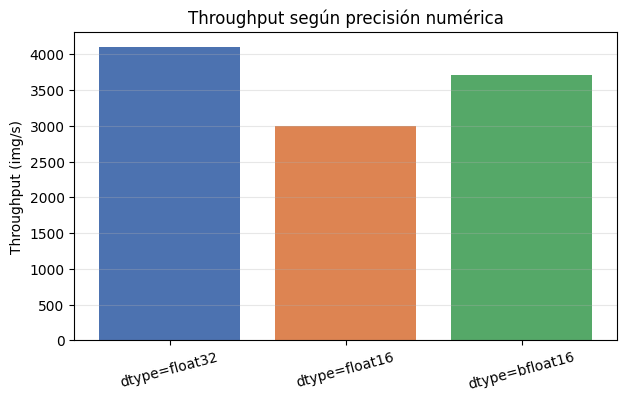

In [21]:
plt.figure(figsize=(7, 4))
plt.bar(df_prec['config'], df_prec['throughput_img_s'], color=['#4C72B0','#DD8452','#55A868'])
plt.ylabel('Throughput (img/s)'); plt.title('Throughput según precisión numérica')
plt.xticks(rotation=15); plt.grid(axis='y', alpha=.3); plt.show()

## 8. Análisis y Discusión

> **Completar con base en los resultados obtenidos al ejecutar.** Guía de respuesta:

1. **¿Qué ventajas ofrece Flax NNX respecto a implementar modelos directamente en JAX?**
   NNX administra automáticamente el estado del modelo (parámetros, estadísticas de BatchNorm, RNGs) con una sintaxis orientada a objetos similar a PyTorch. En JAX puro habría que pasar y actualizar manualmente diccionarios de parámetros en cada función, lo que es propenso a errores.

2. **¿Qué beneficios aporta `jax.jit`?**
   Compila el grafo de operaciones con XLA: fusiona operaciones, optimiza memoria y elimina el overhead de Python. La primera época es más lenta (compilación), pero las siguientes son varias veces más rápidas.

3. **¿Qué hiperparámetro tuvo mayor impacto sobre la exactitud final?** → ver tabla de la sección 6 (típicamente la tasa de aprendizaje).

4. **¿Qué hiperparámetro tuvo mayor impacto sobre el tiempo de entrenamiento?** → típicamente el tamaño de la red y el tamaño de lote.

5. **¿Cómo afectó el tamaño de lote al rendimiento?** → lotes grandes aumentan el throughput (mejor uso del acelerador) pero pueden reducir levemente la exactitud por menos actualizaciones de gradiente.

6. **Diferencias entre float32, float16 y bfloat16** → ver tabla sección 7. bfloat16 suele mantener estabilidad (mismo rango de exponente que float32); float16 puede presentar inestabilidad/NaNs.

7. **Configuración con mejor balance** → ver `best` de la sección 6.

8. **Limitaciones de Google Colab** → tiempo de sesión limitado, GPU compartida con variabilidad, RAM limitada, desconexiones.

9. **Mejoras futuras** → data augmentation, arquitecturas más profundas (ResNet), learning rate schedules, early stopping, transfer learning, entrenamiento multi-dispositivo con sharding.

## 9. Conclusiones

> Completar después de ejecutar: resumir el mejor modelo, su exactitud de prueba, el efecto de JIT y de la precisión numérica, y las lecciones aprendidas sobre el ecosistema JAX/Flax.